# Sentiment Analisis Model

#### Studi kasus analisis sentimen komentar YouTube menggunakan metode Rule Based dan RoBERTa. Dataset diklasifikasikan ke dalam sentimen positif, netral, dan negatif, kemudian dilakukan evaluasi menggunakan label manual untuk mengetahui performa model

In [11]:
import pandas as pd

In [12]:
df = pd.read_csv("Youtube Sentiment_Roberta.csv")
df

,Channel_Sumber,Author,Comment_Final,Likes,Time,Tipe_Komentar,Sentiment_Rule,Sentiment_Roberta
0,Jagat Review,@CheverrlynAdyba,link beli chamon pro 5g,0,2026-03-21 13:04:52+00:00,Utama,Netral,Netral
1,Jagat Review,@caesarrizkie9742,ngomongin rog kah kamera turun lihat review ca...,0,2026-03-17 20:41:02+00:00,Utama,Positif,Positif
2,Jagat Review,@adealfian664,user samsung one ui ui enak ui ui if you can t...,0,2026-03-13 23:27:54+00:00,Utama,Netral,Positif
3,Jagat Review,@RsyatLyioz,tecno pova ultra 5g,0,2026-03-12 20:11:30+00:00,Utama,Netral,Negatif
4,Jagat Review,@CitraUtut,tolong buatin rekomendasi lebaran,2,2026-03-02 23:12:23+00:00,Utama,Positif,Netral
...,...,...,...,...,...,...,...,...
7194,Gadgetin,@imnaps,akhirnyaa rekomendasi,1,2025-12-07 09:27:42+00:00,Utama,Positif,Netral
7195,Gadgetin,@MOLEND95,first wkwkkw,0,2025-12-07 09:27:40+00:00,Utama,Netral,Negatif
7196,Gadgetin,@m.abidalbaqie9527,party popper party popper,0,2025-12-07 09:27:40+00:00,Utama,Netral,Netral
7197,Gadgetin,@tayaaasy8007,sampe skrng kebel loudly crying face loudly cr...,0,2025-12-07 09:27:39+00:00,Utama,Netral,Negatif


## Distribusi Rule

In [13]:
print("=== RULE BASED ===")
display(df["Sentiment_Rule"].value_counts())

=== RULE BASED ===


,count
Sentiment_Rule,
Netral,5479
Positif,1506
Negatif,214


## Distribusi RoBerta

In [14]:
print("=== ROBERTA ===")
display(df["Sentiment_Roberta"].value_counts())

=== ROBERTA ===


,count
Sentiment_Roberta,
Netral,4214
Negatif,1663
Positif,1322


## Crosstab

In [15]:
ct = pd.crosstab(
    df["Sentiment_Rule"],
    df["Sentiment_Roberta"]
)

display(ct)

Sentiment_Roberta,Negatif,Netral,Positif
Sentiment_Rule,,,
Negatif,137,53,24
Netral,1329,3589,561
Positif,197,572,737


In [16]:
ct_percent = pd.crosstab(
    df["Sentiment_Rule"],
    df["Sentiment_Roberta"],
    normalize="index"
) * 100

display(
    ct_percent.round(2)
)

Sentiment_Roberta,Negatif,Netral,Positif
Sentiment_Rule,,,
Negatif,64.02,24.77,11.21
Netral,24.26,65.50,10.24
Positif,13.08,37.98,48.94


## Tabel Perbandingan Hasil (Agreement)

In [17]:
agreement = (
    df["Sentiment_Rule"]
    ==
    df["Sentiment_Roberta"]
).mean() * 100

print(
    "Persentase kesamaan:",
    round(agreement,2),
    "%"
)

Persentase kesamaan: 61.99 %


In [18]:
df["label_manual"] = ""

## Export Tabel Manual

In [19]:
df.to_csv(
    "Data Label Manual.csv",
    index=False,
    encoding="utf-8-sig")

print("CSV berhasil dibuat:")
print("Data Label Manual.csv")

CSV berhasil dibuat:
Data Label Manual.csv


## Import File Label Manual Final

In [20]:
import pandas as pd

df = pd.read_csv("Youtube Label Manual Final.csv")
df

,Channel_Sumber,Author,Comment_Final,Likes,Time,Tipe_Komentar,Sentiment_Rule,Sentiment_Roberta,label_manual
0,Jagat Review,@CheverrlynAdyba,link beli chamon pro 5g,0,2026-03-21 13:04:52+00:00,Utama,Netral,Netral,Netral
1,Jagat Review,@caesarrizkie9742,ngomongin rog kah kamera turun lihat review ca...,0,2026-03-17 20:41:02+00:00,Utama,Positif,Positif,Positif
2,Jagat Review,@adealfian664,user samsung one ui ui enak ui ui if you can t...,0,2026-03-13 23:27:54+00:00,Utama,Netral,Positif,Positif
3,Jagat Review,@RsyatLyioz,tecno pova ultra 5g,0,2026-03-12 20:11:30+00:00,Utama,Netral,Negatif,Negatif
4,Jagat Review,@CitraUtut,tolong buatin rekomendasi lebaran,2,2026-03-02 23:12:23+00:00,Utama,Positif,Netral,Positif
...,...,...,...,...,...,...,...,...,...
7194,Gadgetin,@imnaps,akhirnyaa rekomendasi,1,2025-12-07 09:27:42+00:00,Utama,Positif,Netral,Positif
7195,Gadgetin,@MOLEND95,first wkwkkw,0,2025-12-07 09:27:40+00:00,Utama,Netral,Negatif,Negatif
7196,Gadgetin,@m.abidalbaqie9527,party popper party popper,0,2025-12-07 09:27:40+00:00,Utama,Netral,Netral,Netral
7197,Gadgetin,@tayaaasy8007,sampe skrng kebel loudly crying face loudly cr...,0,2025-12-07 09:27:39+00:00,Utama,Netral,Negatif,Negatif


In [21]:
df.columns

Index(['Channel_Sumber', 'Author', 'Comment_Final', 'Likes', 'Time',
       'Tipe_Komentar', 'Sentiment_Rule', 'Sentiment_Roberta', 'label_manual'],
      dtype='object')

In [22]:
df[
    [
        "Comment_Final",
        "Sentiment_Roberta"
    ]
].head()

,Comment_Final,Sentiment_Roberta
0,link beli chamon pro 5g,Netral
1,ngomongin rog kah kamera turun lihat review ca...,Positif
2,user samsung one ui ui enak ui ui if you can t...,Positif
3,tecno pova ultra 5g,Negatif
4,tolong buatin rekomendasi lebaran,Netral


In [23]:
df[
    [
        "Comment_Final",
        "Sentiment_Rule"
    ]
].head()

,Comment_Final,Sentiment_Rule
0,link beli chamon pro 5g,Netral
1,ngomongin rog kah kamera turun lihat review ca...,Positif
2,user samsung one ui ui enak ui ui if you can t...,Netral
3,tecno pova ultra 5g,Netral
4,tolong buatin rekomendasi lebaran,Positif


In [24]:
brands = [

    "samsung",
    "xiaomi",
    "redmi",
    "poco",
    "apple",
    "iphone",
    "oppo",
    "vivo",
    "realme",
    "infinix",
    "tecno",
    "asus",
    "rog",
    "nokia",
    "huawei",
    "honor",
    "iqoo",
    "lenovo",
    "motorola",
    "sony",
    "xperia",
    "google",
    "pixel",
    "oneplus",
    "nubia",
    "zte",
    "meizu",
    "blackberry",
    "sharp",
    "coolpad"
]

In [25]:
def ambil_brand(teks):

    teks = str(teks).lower()

    for brand in brands:

        if brand in teks:

            # Xiaomi family
            if brand in [
                "xiaomi",
                "redmi",
                "poco"
            ]:
                return "Xiaomi"

            # Apple family
            if brand in [
                "iphone",
                "apple"
            ]:
                return "Apple"

            # Asus family
            if brand in [
                "asus",
                "rog"
            ]:
                return "Asus"

            # Sony family
            if brand in [
                "sony",
                "xperia"
            ]:
                return "Sony"

            # Google family
            if brand in [
                "google",
                "pixel"
            ]:
                return "Google"

            # sisanya otomatis kapital awal
            return brand.title()

    return "Tidak Terdeteksi"

In [26]:
df["Brand"] = df["Comment_Final"].apply(ambil_brand)

In [27]:
display(df[["Comment_Final","Brand"]].head(15))

,Comment_Final,Brand
0,link beli chamon pro 5g,Tidak Terdeteksi
1,ngomongin rog kah kamera turun lihat review ca...,Asus
2,user samsung one ui ui enak ui ui if you can t...,Samsung
3,tecno pova ultra 5g,Tecno
4,tolong buatin rekomendasi lebaran,Tidak Terdeteksi
5,infinix gt30 pro harga juta tau harga asli jut...,Infinix
6,beli toko,Tidak Terdeteksi
7,samsung s24fe5g aman kah beli,Samsung
8,bingung seri juta bagus bagus beli handphone l...,Infinix
9,camera camon game gt,Tidak Terdeteksi


In [28]:
display(df["Brand"].value_counts())

,count
Brand,
Tidak Terdeteksi,3990
Xiaomi,977
Infinix,472
Samsung,417
Motorola,271
Tecno,190
Oppo,180
Vivo,155
Apple,142


In [29]:
belum = df[
    df["Brand"]
    ==
    "Tidak Terdeteksi"
]

display(
    belum[
        ["Comment_Final"]
    ].sample(30)
)

,Comment_Final
740,tunggu tunggu smiling face with smiling eyes
5586,et et editor cat with tears of joy
6113,bingung handphone kamera bagus
2363,youtube utama lihat review kamera red heart
3811,moga kebel x300 palms up together light skin t...
1901,mang suruh milih camon pro vs infinik gt pro m...
2667,game sosmed harga 2jutaan ya
3218,xiomi not 14pro 5g masuk
6712,kaget x15tp menang
2622,handphone ngojek kakak


## Accuracy, Precision, Recall, F1 Scpre

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [31]:
y_true = df["label_manual"]
y_rule = df["Sentiment_Rule"]
y_roberta = df["Sentiment_Roberta"]

Rule Based

In [32]:
print(
    "Accuracy :", round(accuracy_score(y_true, y_rule), 4),
    "| Precision :", round(precision_score(y_true, y_rule, average="weighted"), 4),
    "| Recall :", round(recall_score(y_true, y_rule, average="weighted"), 4),
    "| F1 Score :", round(f1_score(y_true, y_rule, average="weighted"), 4)
)

Accuracy : 0.6993 | Precision : 0.742 | Recall : 0.6993 | F1 Score : 0.6486


RoBERTa

In [33]:
print(
    "Accuracy :", round(accuracy_score(y_true, y_roberta), 4),
    "| Precision :", round(precision_score(y_true, y_roberta, average="weighted"), 4),
    "| Recall :", round(recall_score(y_true, y_roberta, average="weighted"), 4),
    "| F1 Score :", round(f1_score(y_true, y_roberta, average="weighted"), 4)
)

Accuracy : 0.8737 | Precision : 0.8864 | Recall : 0.8737 | F1 Score : 0.8656


## Confusion Matrix

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

Rule Based

In [35]:
cm_rule = pd.crosstab(
    df["label_manual"],
    df["Sentiment_Rule"],
    rownames=["Label Manual"],
    colnames=["Prediksi Rule Based"]
)

print("=== CONFUSION MATRIX RULE BASED ===")

display(cm_rule)

=== CONFUSION MATRIX RULE BASED ===


Prediksi Rule Based,Negatif,Netral,Positif
Label Manual,,,
Negatif,164,1267,40
Netral,30,3511,107
Positif,20,701,1359


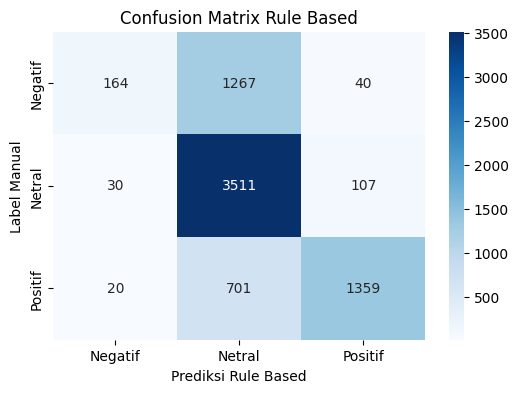

In [36]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rule,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix Rule Based")
plt.ylabel("Label Manual")
plt.xlabel("Prediksi Rule Based")

plt.show()

RoBERTa

In [37]:
cm_roberta = pd.crosstab(
    df["label_manual"],
    df["Sentiment_Roberta"],
    rownames=["Label Manual"],
    colnames=["Prediksi RoBERTa"]
)

print("=== CONFUSION MATRIX ROBERTA ===")

display(cm_roberta)

=== CONFUSION MATRIX ROBERTA ===


Prediksi RoBERTa,Negatif,Netral,Positif
Label Manual,,,
Negatif,1423,30,18
Netral,47,3582,19
Positif,193,602,1285


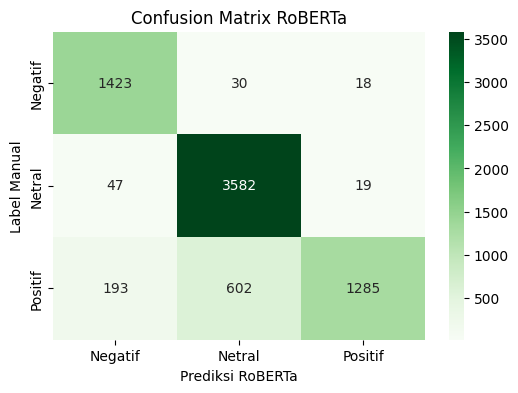

In [38]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_roberta,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Confusion Matrix RoBERTa")
plt.ylabel("Label Manual")
plt.xlabel("Prediksi RoBERTa")

plt.show()

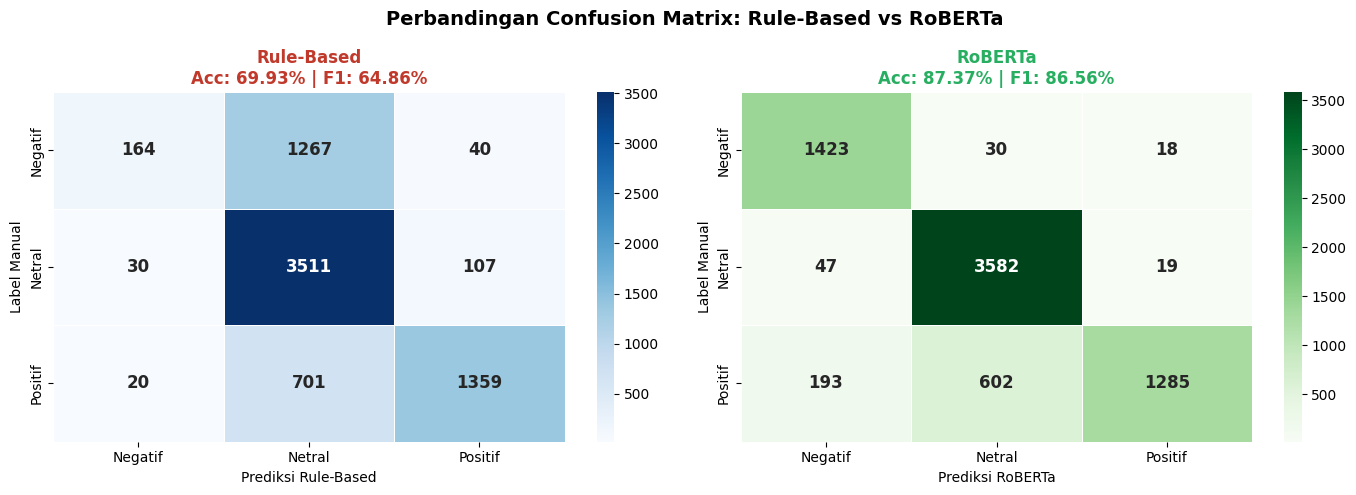

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rule-Based
sns.heatmap(cm_rule, annot=True, fmt='d', cmap='Blues',
            ax=axes[0], linewidths=0.5,
            annot_kws={'size': 12, 'weight': 'bold'})
axes[0].set_title(f'Rule-Based\nAcc: 69.93% | F1: 64.86%',
                  fontsize=12, color='#c0392b', fontweight='bold')
axes[0].set_ylabel('Label Manual')
axes[0].set_xlabel('Prediksi Rule-Based')

# RoBERTa
sns.heatmap(cm_roberta, annot=True, fmt='d', cmap='Greens',
            ax=axes[1], linewidths=0.5,
            annot_kws={'size': 12, 'weight': 'bold'})
axes[1].set_title(f'RoBERTa\nAcc: 87.37% | F1: 86.56%',
                  fontsize=12, color='#27ae60', fontweight='bold')
axes[1].set_ylabel('Label Manual')
axes[1].set_xlabel('Prediksi RoBERTa')

plt.suptitle('Perbandingan Confusion Matrix: Rule-Based vs RoBERTa',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Classification Report

In [40]:
print("=== RULE BASED ===")

print(classification_report(y_true,y_rule))
print()

=== RULE BASED ===
              precision    recall  f1-score   support

     Negatif       0.77      0.11      0.19      1471
      Netral       0.64      0.96      0.77      3648
     Positif       0.90      0.65      0.76      2080

    accuracy                           0.70      7199
   macro avg       0.77      0.58      0.57      7199
weighted avg       0.74      0.70      0.65      7199




Rule Based cenderung mengklasifikasikan komentar ke kelas netral, sehingga performa pada kelas negatif masih rendah.

In [41]:
print(
    "=== CONTOH KOMENTAR SALAH PREDIKSI RULE BASED ==="
)

mis_rule = df[
    df["label_manual"]
    !=
    df["Sentiment_Rule"]
]

display(
    mis_rule[
        [
            "Comment_Final",
            "label_manual",
            "Sentiment_Rule"
        ]
    ].head(10)
)

=== CONTOH KOMENTAR SALAH PREDIKSI RULE BASED ===


,Comment_Final,label_manual,Sentiment_Rule
2,user samsung one ui ui enak ui ui if you can t...,Positif,Netral
3,tecno pova ultra 5g,Negatif,Netral
16,pentingin kembangin dingin mesin dah kembang h...,Positif,Netral
19,iqoo z10 pakai layar p oled amoled,Netral,Positif
20,infinix gt pro non gaming rekomended,Netral,Positif
23,yawning face sleeping face sleepy face zz,Negatif,Netral
27,bingung z9 z10,Negatif,Netral
28,motorola paman kog masuk sihh,Negatif,Netral
32,gaming juta,Netral,Positif
36,bingung pova curve 5g gt30 5g,Negatif,Netral


In [42]:
print("=== ROBERTA ===")

print(classification_report(y_true,y_roberta))

=== ROBERTA ===
              precision    recall  f1-score   support

     Negatif       0.86      0.97      0.91      1471
      Netral       0.85      0.98      0.91      3648
     Positif       0.97      0.62      0.76      2080

    accuracy                           0.87      7199
   macro avg       0.89      0.86      0.86      7199
weighted avg       0.89      0.87      0.87      7199



RoBERTa mampu memahami konteks kalimat lebih baik dibanding Rule Based sehingga menghasilkan klasifikasi sentimen yang lebih akurat.

In [43]:
print(
    "=== CONTOH KOMENTAR SALAH PREDIKSI ROBERTA ==="
)

mis_roberta = df[
    df["label_manual"]
    !=
    df["Sentiment_Roberta"]
]

display(
    mis_roberta[
        [
            "Comment_Final",
            "label_manual",
            "Sentiment_Roberta"
        ]
    ].head(10)
)

=== CONTOH KOMENTAR SALAH PREDIKSI ROBERTA ===


,Comment_Final,label_manual,Sentiment_Roberta
4,tolong buatin rekomendasi lebaran,Positif,Netral
8,bingung seri juta bagus bagus beli handphone l...,Positif,Negatif
11,redmi note 5g ultrawide murah chipset 5g,Positif,Netral
26,dear tim jr request video rekomendasi jelang l...,Positif,Netral
31,kliling lihat rekomendasi jt bagus motorola ed...,Positif,Netral
33,infinix gt pro versi murah ya infinix gt,Positif,Netral
59,poco x7 pro ok kah masuk range harga ready off...,Positif,Negatif
65,binggung tecno camo pro beli review,Netral,Negatif
69,motorola fusion pro masuk yak ram langit bener...,Positif,Negatif
84,harga ram worth it g ya,Positif,Negatif


## Kesimpulan :
Berdasarkan hasil confusion matrix dan classification report, model Rule Based memperoleh accuracy 69,93%, precision weighted 74,20%, recall weighted 69,93%, dan F1-score weighted 64,86%. Model ini cukup baik dalam mendeteksi komentar netral dan positif, namun masih kurang optimal pada kelas negatif karena beberapa komentar negatif masih terprediksi sebagai netral.

Sementara itu, model RoBERTa memperoleh accuracy 87,37%, precision weighted 88,64%, recall weighted 87,37%, dan F1-score weighted 86,56%. Hasil ini menunjukkan bahwa RoBERTa lebih baik dalam memahami konteks komentar YouTube, termasuk bahasa informal dan variasi penulisan.

Evaluasi menggunakan weighted average karena distribusi data komentar tidak seimbang, dengan komentar netral lebih dominan dibanding positif dan negatif. Berdasarkan seluruh hasil evaluasi, RoBERTa dipilih sebagai model terbaik karena memberikan performa paling tinggi pada seluruh metrik evaluasi dan lebih representatif terhadap data komentar YouTube.

In [44]:
comparison = pd.DataFrame({
    'Model'    : ['Rule-Based', 'RoBERTa'],
    'Accuracy' : [0.6993, 0.8737],
    'Precision': [0.7420, 0.8864],
    'Recall'   : [0.6993, 0.8737],
    'F1-Score' : [0.6486, 0.8656],
})
comparison = comparison.set_index('Model')


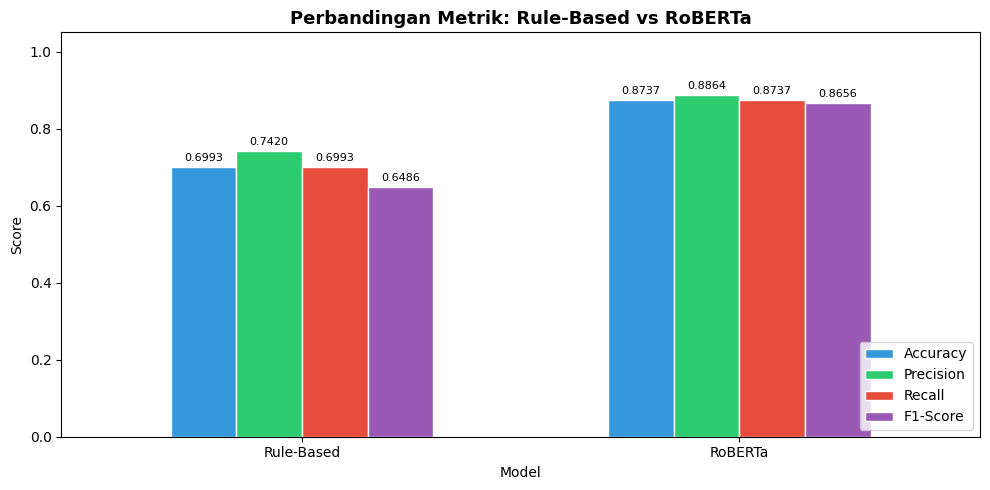


=== TABEL RINGKASAN METRIK ===
            Accuracy  Precision  Recall  F1-Score
Model                                            
Rule-Based    0.6993     0.7420  0.6993    0.6486
RoBERTa       0.8737     0.8864  0.8737    0.8656

RoBERTa lebih baik dari Rule-Based di semua metrik:
  Accuracy  : +17.4%
  F1-Score  : +21.7%


In [45]:
ax = comparison.plot(kind='bar', figsize=(10, 5), rot=0,
                     color=['#3498db','#2ecc71','#e74c3c','#9b59b6'],
                     edgecolor='white', width=0.6)
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3, fontsize=8)
plt.title('Perbandingan Metrik: Rule-Based vs RoBERTa', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("\n=== TABEL RINGKASAN METRIK ===")
print(comparison.to_string())
print(f"\nRoBERTa lebih baik dari Rule-Based di semua metrik:")
print(f"  Accuracy  : +{(0.8737-0.6993)*100:.1f}%")
print(f"  F1-Score  : +{(0.8656-0.6486)*100:.1f}%")


## Justifikasi Penggunaan Weighted Sentiment

Evaluasi model sentiment analysis menggunakan weighted average karena distribusi data komentar YouTube pada masing-masing kelas sentimen tidak seimbang. Berdasarkan hasil label manual, jumlah komentar netral lebih dominan dibanding komentar negatif dan positif. Kondisi tersebut menyebabkan setiap kelas memiliki jumlah data yang berbeda.

Apabila menggunakan rata-rata biasa (macro average), setiap kelas sentimen akan diberi bobot yang sama tanpa memperhatikan jumlah data pada masing-masing kelas. Hal tersebut dapat menyebabkan hasil evaluasi kurang merepresentasikan kondisi data yang sebenarnya.

Oleh karena itu digunakan weighted average karena perhitungan precision dan recall mempertimbangkan proporsi jumlah data pada setiap kelas sentimen. Dengan demikian hasil evaluasi menjadi lebih representatif terhadap keseluruhan dataset komentar YouTube dan sesuai untuk analisis Big Data yang memiliki volume data besar dan distribusi kelas yang tidak seimbang.

## Simpan Hasil

In [46]:
agg = df["Sentiment_Roberta"]\
    .value_counts()\
    .reset_index()

agg.columns = [
    "Sentiment",
    "Jumlah"
]

display(agg)

agg.to_csv(
    "Youtube Sentiment Evaluation Final.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "File Youtube Sentiment Evaluation Final.csv berhasil disimpan"
)

,Sentiment,Jumlah
0,Netral,4214
1,Negatif,1663
2,Positif,1322


File Youtube Sentiment Evaluation Final.csv berhasil disimpan


In [47]:
import numpy as np

# Agregasi per brand dengan kolom lebih lengkap
brand_full = df.groupby('Brand').agg(
    Positif  = ('Sentiment_Roberta', lambda x: (x == 'Positif').sum()),
    Netral   = ('Sentiment_Roberta', lambda x: (x == 'Netral').sum()),
    Negatif  = ('Sentiment_Roberta', lambda x: (x == 'Negatif').sum()),
    Total    = ('Sentiment_Roberta', 'count'),
).reset_index()

# Hapus baris "Tidak Terdeteksi"
brand_full = brand_full[brand_full['Brand'] != 'Tidak Terdeteksi']

# Hitung sentiment score & weighted sentiment
brand_full['Sentiment_Score_Avg'] = (
    (brand_full['Positif'] - brand_full['Negatif']) / brand_full['Total']
).round(4)

brand_full['Weighted_Sentiment'] = (
    brand_full['Sentiment_Score_Avg'] * np.log1p(brand_full['Total'])
).round(4)

brand_full['Positif_Pct'] = (brand_full['Positif'] / brand_full['Total'] * 100).round(1)
brand_full['Negatif_Pct'] = (brand_full['Negatif'] / brand_full['Total'] * 100).round(1)

# Sort by weighted sentiment
brand_full = brand_full.sort_values('Weighted_Sentiment', ascending=False)

print("=== SENTIMENT BRAND AGG (LENGKAP) ===")
display(brand_full)

=== SENTIMENT BRAND AGG (LENGKAP) ===


,Brand,Positif,Netral,Negatif,Total,Sentiment_Score_Avg,Weighted_Sentiment,Positif_Pct,Negatif_Pct
20,Vivo,36,102,17,155,0.1226,0.6191,23.2,11.0
21,Xiaomi,215,632,130,977,0.0870,0.5990,22.0,13.3
17,Sony,2,7,0,9,0.2222,0.5116,22.2,0.0
5,Infinix,96,313,63,472,0.0699,0.4305,20.3,13.3
0,Apple,40,74,28,142,0.0845,0.4194,28.2,19.7
15,Samsung,78,288,51,417,0.0647,0.3905,18.7,12.2
10,Nokia,2,2,1,5,0.2000,0.3584,40.0,20.0
7,Lenovo,2,5,1,8,0.1250,0.2747,25.0,12.5
8,Meizu,0,1,0,1,0.0000,0.0000,0.0,0.0
12,Oneplus,0,4,0,4,0.0000,0.0000,0.0,0.0


In [48]:
brand_full.to_csv('sentiment_brand_agg.csv', index=False, encoding='utf-8-sig')
print("✅ sentiment_brand_agg.csv berhasil disimpan!")
print(f"   {len(brand_full)} brand | kolom: {brand_full.columns.tolist()}")

✅ sentiment_brand_agg.csv berhasil disimpan!
   21 brand | kolom: ['Brand', 'Positif', 'Netral', 'Negatif', 'Total', 'Sentiment_Score_Avg', 'Weighted_Sentiment', 'Positif_Pct', 'Negatif_Pct']


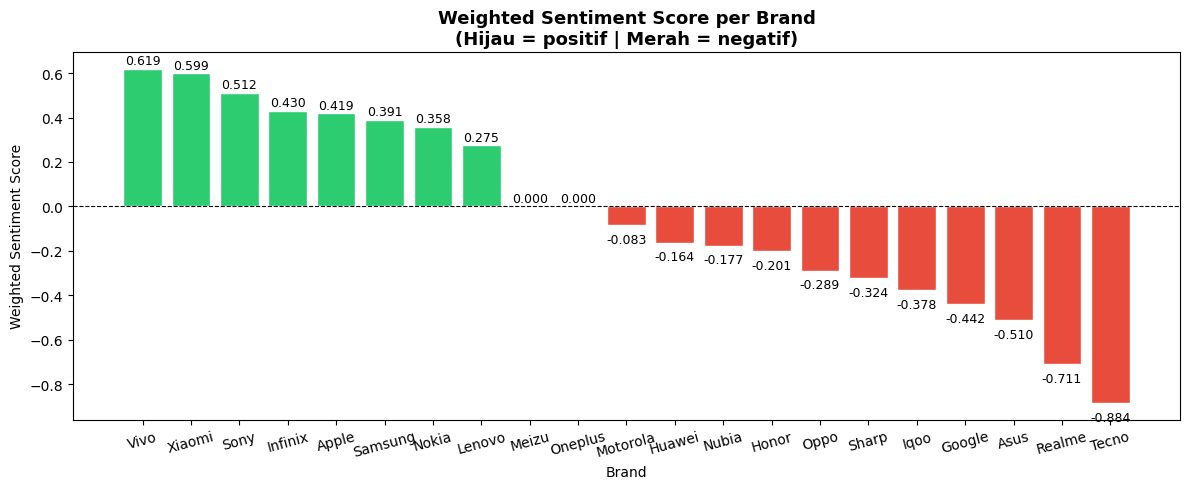

In [49]:
plt.figure(figsize=(12, 5))

colors_bar = [
    '#2ecc71' if v >= 0 else '#e74c3c'
    for v in brand_full['Weighted_Sentiment']
]

ax = plt.gca()

bars = ax.bar(
    brand_full['Brand'],
    brand_full['Weighted_Sentiment'],
    color=colors_bar,
    edgecolor='white'
)

for bar in bars:
    h = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + (0.02 if h >= 0 else -0.08),
        f'{h:.3f}',
        ha='center',
        fontsize=9
    )

ax.axhline(
    0,
    color='black',
    linewidth=0.8,
    linestyle='--'
)

plt.title(
    'Weighted Sentiment Score per Brand\n(Hijau = positif | Merah = negatif)',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Brand')
plt.ylabel('Weighted Sentiment Score')

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()